In [3]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("titanic")

df.to_csv("titanic.csv", index=False)

In [4]:
print("Dataset information:")
df.info()

print("\nDataset description:")
print(df.describe())

print("\nDataset shape:")
print(df.shape)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB

Dataset description:
         survived      pclass         age       si

In [5]:
missing_percent = df.isnull().mean() * 100

print(missing_percent)

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [6]:
df['age']=df['age'].fillna(df['age'].median())
df=df.dropna(subset=['embarked','embark_town'])
df=df.drop(columns=['deck'])

print("Shape after missing-value handling:")
print(df.shape)

print("\nRemaining missing values:")
print(df.isnull().sum())

Shape after missing-value handling:
(889, 14)

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [7]:
df.to_csv("titanic_cleaned.csv", index=False)

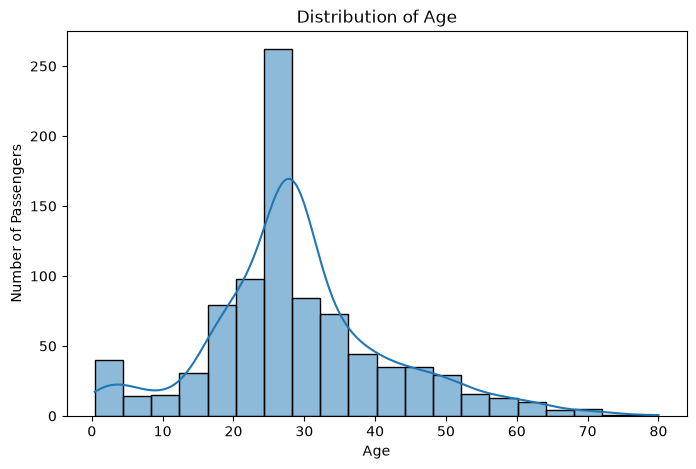

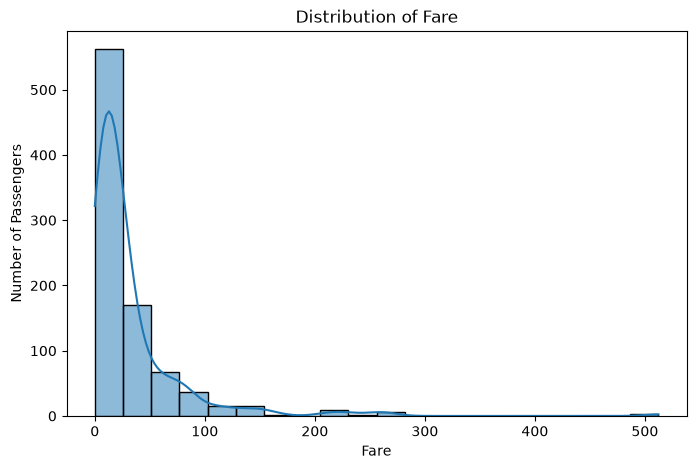

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["fare"], bins=20, kde=True)
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()

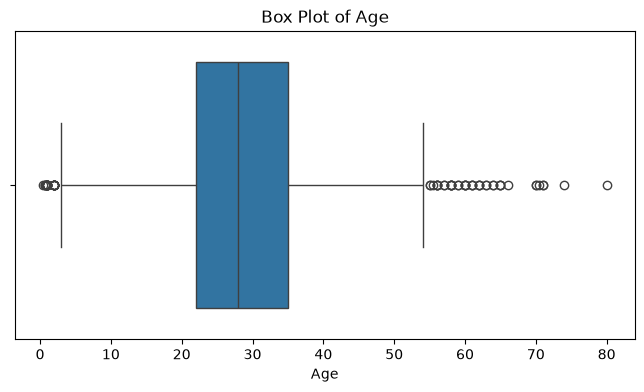

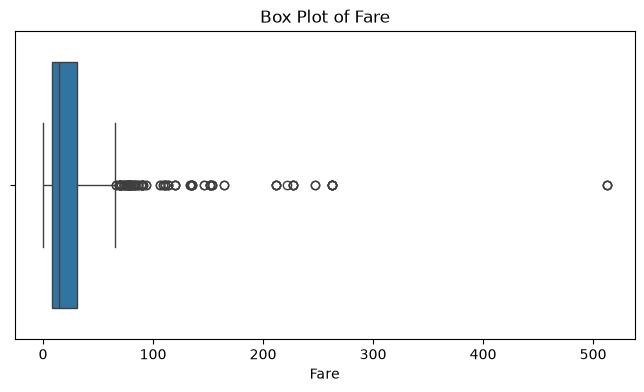

In [9]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["age"])
plt.title("Box Plot of Age")
plt.xlabel("Age")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df["fare"])
plt.title("Box Plot of Fare")
plt.xlabel("Fare")
plt.show()

In [10]:
age_q1 = df["age"].quantile(0.25)
age_q3 = df["age"].quantile(0.75)

age_iqr = age_q3 - age_q1

age_lower = age_q1 - 1.5 * age_iqr
age_upper = age_q3 + 1.5 * age_iqr

age_outliers = df[
    (df["age"] < age_lower) |
    (df["age"] > age_upper)
]

print("Age IQR:", age_iqr)
print("Age lower bound:", age_lower)
print("Age upper bound:", age_upper)
print("Age outlier count:", len(age_outliers))

Age IQR: 13.0
Age lower bound: 2.5
Age upper bound: 54.5
Age outlier count: 65


In [11]:
fare_q1 = df["fare"].quantile(0.25)
fare_q3 = df["fare"].quantile(0.75)

fare_iqr = fare_q3 - fare_q1

fare_lower = fare_q1 - 1.5 * fare_iqr
fare_upper = fare_q3 + 1.5 * fare_iqr

fare_outliers = df[
    (df["fare"] < fare_lower) |
    (df["fare"] > fare_upper)
]

print("Fare IQR:", fare_iqr)
print("Fare lower bound:", fare_lower)
print("Fare upper bound:", fare_upper)
print("Fare outlier count:", len(fare_outliers))

Fare IQR: 23.1042
Fare lower bound: -26.7605
Fare upper bound: 65.6563
Fare outlier count: 114


In [12]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print("Fare mean:", fare_mean)
print("Fare median:", fare_median)
print("Fare mode:", fare_mode)

Fare mean: 32.09668087739032
Fare median: 14.4542
Fare mode: 8.05


In [13]:
print("Survival rate by sex:")
print(df.groupby("sex")["survived"].mean())

Survival rate by sex:
sex
female    0.740385
male      0.188908
Name: survived, dtype: float64


In [14]:
print("Survival rate by passenger class:")
print(df.groupby("pclass")["survived"].mean())

Survival rate by passenger class:
pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64


In [15]:
print("Survival rate by sex and passenger class:")
print(df.groupby(["sex", "pclass"])["survived"].mean())

Survival rate by sex and passenger class:
sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


In [16]:
female_first = df[
    (df["sex"] == "female") &
    (df["pclass"] == 1)
]

print("Female first-class passengers:")
print(female_first[["sex", "pclass", "survived"]].head())

Female first-class passengers:
       sex  pclass  survived
1   female       1         1
3   female       1         1
11  female       1         1
31  female       1         1
52  female       1         1


In [17]:
female_or_first = df[
    (df["sex"] == "female") |
    (df["pclass"] == 1)
]

print("Passengers who are female OR first class:")
print(female_or_first[["sex", "pclass", "survived"]].head())

Passengers who are female OR first class:
      sex  pclass  survived
1  female       1         1
2  female       3         1
3  female       1         1
6    male       1         0
8  female       3         1


In [18]:
corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[corr_columns].corr()

print(corr_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


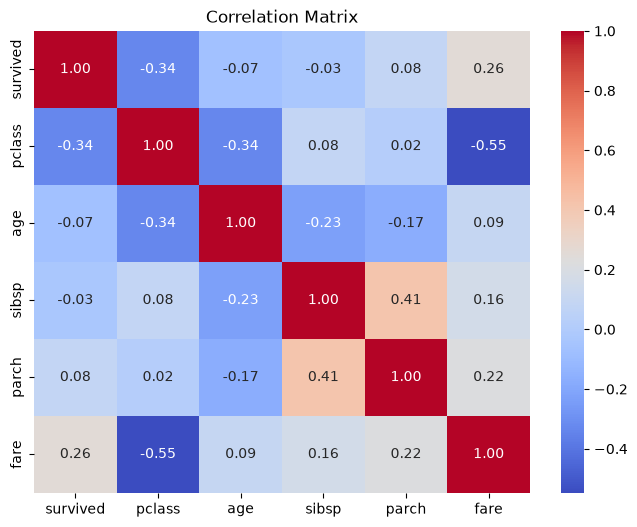

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

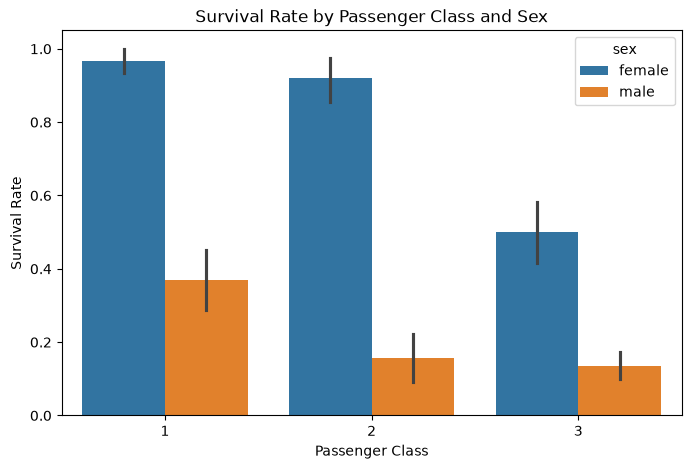

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

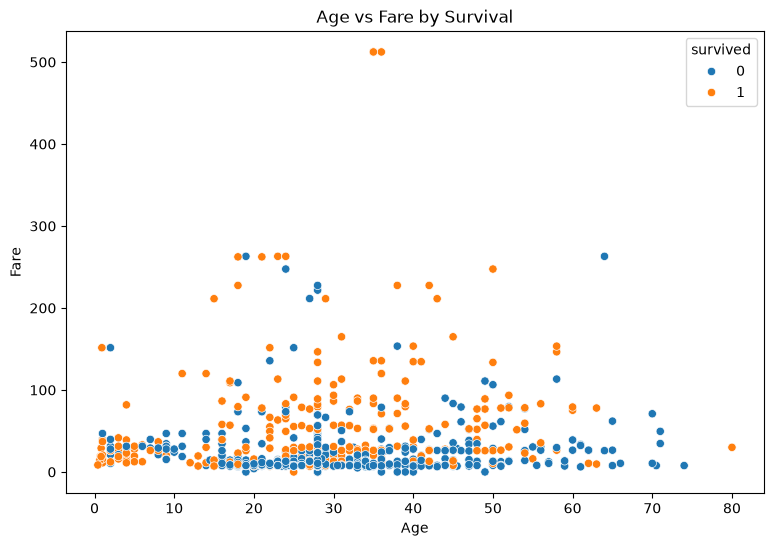

In [21]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived"
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

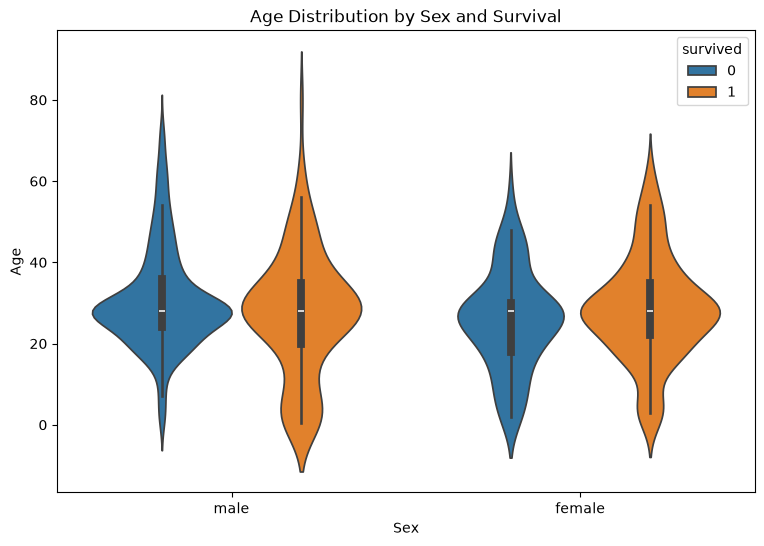

In [22]:
plt.figure(figsize=(9, 6))

sns.violinplot(
    data=df,
    x="sex",
    y="age",
    hue="survived"
)

plt.title("Age Distribution by Sex and Survival")
plt.xlabel("Sex")
plt.ylabel("Age")
plt.show()

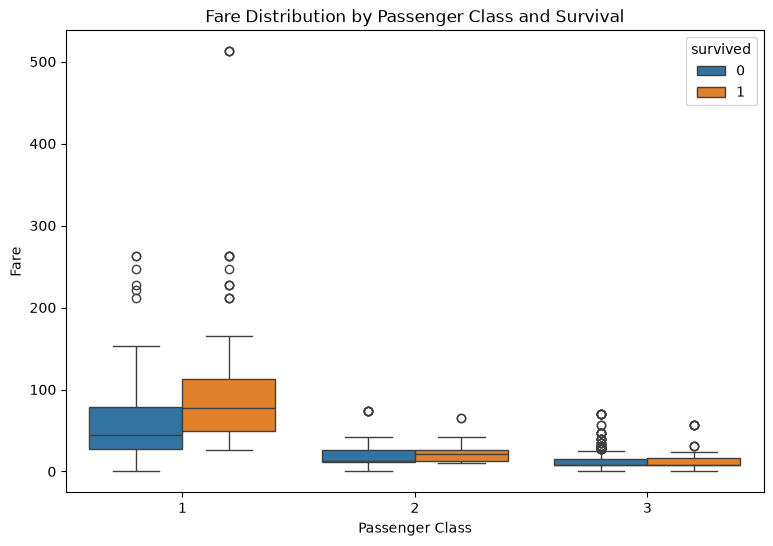

In [23]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="pclass",
    y="fare",
    hue="survived"
)

plt.title("Fare Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

In [24]:
eda_standardized = df[["age", "fare"]].copy()

eda_standardized["age_z"] = (
    eda_standardized["age"] - eda_standardized["age"].mean()
) / eda_standardized["age"].std(ddof=0)

eda_standardized["fare_z"] = (
    eda_standardized["fare"] - eda_standardized["fare"].mean()
) / eda_standardized["fare"].std(ddof=0)

print("Before standardization:")
print(eda_standardized[["age", "fare"]].mean())
print(eda_standardized[["age", "fare"]].std(ddof=0))

print("\nAfter standardization:")
print(eda_standardized[["age_z", "fare_z"]].mean())
print(eda_standardized[["age_z", "fare_z"]].std(ddof=0))

Before standardization:
age     29.315152
fare    32.096681
dtype: float64
age     12.977627
fare    49.669545
dtype: float64

After standardization:
age_z     2.717486e-16
fare_z    1.398706e-16
dtype: float64
age_z     1.0
fare_z    1.0
dtype: float64
